In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv', index_col=0)
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax
jax.config.update('jax_platform_name', 'gpu')

import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from dynamax.hidden_markov_model import LinearRegressionHMM

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
def train_hmm(model, emissions, inputs, verbose = True):
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions, inputs = inputs, num_iters = 10,verbose = verbose)
    return model, fit_params, lps

## Data

In [5]:
# Data Prepping

# copy r_table completely to keep backup
rdf = r_table.copy()

# Add 2 more columns,
# - target at previous trial
# - response at previous trial

rdf['prev_target'] = rdf.groupby(['subj', 'sess', 'run'])['t_calib'].shift(1)
rdf['prev_resp']   = rdf.groupby(['subj', 'sess', 'run'])['resp'].shift(1)

# Replace NaN values in the first trial of each group with the current trial's value
rdf['prev_target'] = rdf['prev_target'].fillna(rdf['t_calib'])
rdf['prev_resp']   = rdf['prev_resp'].fillna(rdf['resp'])

rdf.head()


,subj,sess,run,trial,target,t_calib,resp,resp_err,v_err,exp,...,2sig,nn_c,att,coh,exp_al,f_onset,f_resp,dir,prev_target,prev_resp
0,1,0,0,0,159.0,145.788047,148.685925,2.897877,2.897877,145.788047,...,1.0,1.0,divided,high,expected,132,373,higher,145.788047,148.685925
1,1,0,0,1,123.0,136.060195,129.253756,6.806439,-6.806439,145.788047,...,1.0,1.0,focused,high,unexpected,204,280,lower,145.788047,148.685925
2,1,0,0,2,51.0,33.954344,124.965094,91.010750,91.010750,145.788047,...,0.0,0.0,focused,high,unexpected,168,250,higher,136.060195,129.253756
3,1,0,0,3,159.0,145.788047,145.702460,0.085587,-0.085587,145.788047,...,1.0,1.0,divided,high,expected,168,337,lower,33.954344,124.965094
4,1,0,0,4,15.0,18.896223,144.334808,125.438585,125.438585,145.788047,...,0.0,0.0,divided,low,unexpected,180,270,higher,145.788047,145.702460


In [208]:
rt = (r_table.f_resp.values - 250).reshape(12, 4, 6, 120)[1]*(1000/120)
rt.max(), rt.min(), rt.mean(), rt.std()

(1991.6666666666667,
 133.33333333333334,
 1075.3559027777778,
 257.40619858971985)

In [209]:
emissions = jnp.array((rt/rt.max()).reshape(-1, 120,1))
# inputs = (jnp.tile(jnp.arange(120), (24))/120).reshape(-1, 120, 1)

num_timesteps = 120
decay_timesteps = 25
epsilon = 1e-3
k = -jnp.log(epsilon) / decay_timesteps

t = jnp.arange(num_timesteps)

# Compute exponential decay for t < decay_timesteps and 0 afterwards:
decay_values_piecewise = jnp.where(t < decay_timesteps, jnp.exp(-k * t), 0.0)

# Tile for 24 samples:
inputs = jnp.tile(decay_values_piecewise[None, :, None], (24, 1, 1))

emissions.shape, inputs.shape

((24, 120, 1), (24, 120, 1))

In [210]:
idx = 0
num_states, input_dim, emission_dim = 2, 1, 1

s_em = emissions
s_in = inputs

In [211]:
crossval_results = {}
crossval_results[idx] = {}
shuffle_idx = np.random.permutation(len(s_em))

for nstate in tqdm(range(2, 10), desc=f'sub-{idx+1}'):
    model = LinearRegressionHMM(nstate, input_dim, emission_dim)
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = s_em)
    ll_mean, ll = cross_validate_regressor(model=model, emissions=s_em[shuffle_idx], key=jr.PRNGKey(0), num_iters=100, inputs=s_in[shuffle_idx], init = (parameters, properties), num_folds = 5)
    crossval_results[idx][nstate] = ll

sub-1: 100%|██████████| 8/8 [01:34<00:00, 11.86s/it]


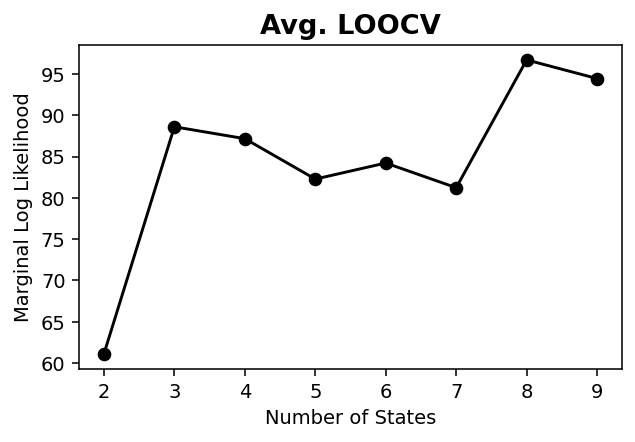

In [212]:
# Lets take a look at the cross validated log likelihoods
plt.figure(figsize=(5, 3))
# marginal likelihoods in y axis
plt.plot(np.arange(8), [np.mean([crossval_results[0][j]]) for j in range(2, 10)], marker='o', label='Mean', color='black')
plt.xticks(np.arange(8), np.arange(2, 10))
plt.xlabel('Number of States')
plt.ylabel('Marginal Log Likelihood')
plt.title('Avg. LOOCV', fontsize=14, weight='bold')
plt.show()

In [213]:
subject_params = {}
subject_params[idx] = {}
shuffle_idx = np.random.permutation(len(s_em))

nstate = 3
model = LinearRegressionHMM(nstate, input_dim, emission_dim)
parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = s_em)
fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = s_em[shuffle_idx], inputs = s_in[shuffle_idx], num_iters = 100, verbose = False)

subject_params[idx][nstate] = fit_params

In [214]:
weights = []
biases = []
transitions = []
covs = []

for i in range(1):
    weights.append(subject_params[i][3].emissions.weights)
    biases.append(subject_params[i][3].emissions.biases)
    transitions.append(subject_params[i][3].transitions.transition_matrix)
    covs.append(subject_params[i][3].emissions.covs)

weights = np.array(weights)
biases = np.array(biases)
transitions = np.array(transitions)
covs = np.array(covs)

weights = weights.transpose(0,1,3,2).reshape(1, 3, 1)
biases = biases.reshape(1, 3)
transitions = transitions.reshape(1, 3, 3)
covs = covs.reshape(1, 3)

In [215]:
weights

array([[[-1.4848316],
        [-0.5767946],
        [-0.0840721]]], dtype=float32)

Text(0.5, 1.0, 'wt on exponential time')

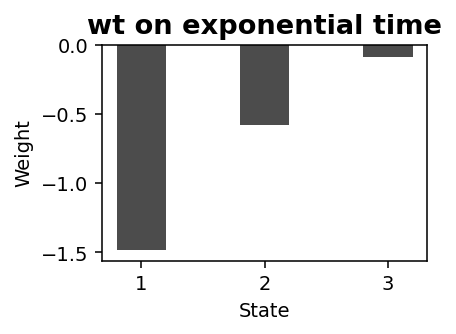

In [216]:
# barchart the 3 weights for each state
plt.figure(figsize=(3, 2))
plt.bar(np.arange(3), weights.reshape(-1), width=0.4, color='black', alpha=0.7)

plt.xticks(np.arange(3), np.arange(1, 4))
plt.ylabel('Weight')
plt.xlabel('State')
plt.title('wt on exponential time', fontsize=14, weight='bold')

Text(0.5, 1.0, 'bias on exponential time')

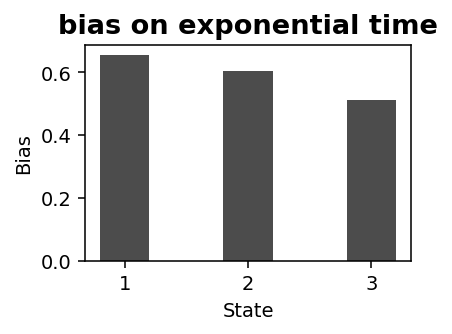

In [219]:
# now do bias
plt.figure(figsize=(3, 2))
plt.bar(np.arange(3), biases.reshape(-1), width=0.4, alpha=0.7, color='black')
plt.xticks(np.arange(3), np.arange(1, 4))
plt.ylabel('Bias')
plt.xlabel('State')
plt.title('bias on exponential time', fontsize=14, weight='bold')

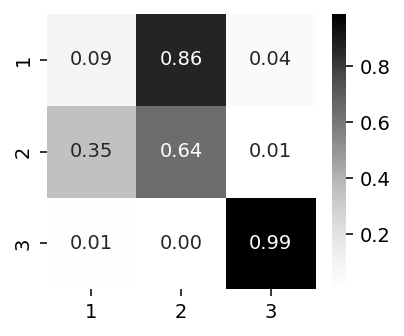

In [220]:
plt.figure(figsize=(3, 2.5))
sns.heatmap(transitions.reshape(3, 3), annot=True, fmt='.2f', cmap='Grays', cbar=True)
# aspect ratio square
plt.xticks(np.arange(0.5, 3, 1), np.arange(1, 4))
plt.yticks(np.arange(0.5, 3, 1), np.arange(1, 4))
plt.tight_layout()

In [221]:
biases

array([[0.65471834, 0.6038823 , 0.51161236]], dtype=float32)

In [222]:
transitions

array([[[0.09227102, 0.8635315 , 0.04419761],
        [0.35278964, 0.63687384, 0.01033649],
        [0.01086286, 0.00280814, 0.986329  ]]], dtype=float32)

In [223]:
covs 

array([[0.01999779, 0.0143162 , 0.01250185]], dtype=float32)

In [224]:
weights

array([[[-1.4848316],
        [-0.5767946],
        [-0.0840721]]], dtype=float32)

In [225]:
s_em.shape

(24, 120, 1)

In [226]:
shuffle_idx = np.random.permutation(len(s_em.reshape(-1, 120, 1)))
em = jnp.array(s_em.reshape(-1, 120, 1)[shuffle_idx])
inps = jnp.array(s_in.reshape(-1, 120, 1)[shuffle_idx])
model = LinearRegressionHMM(nstate, input_dim, emission_dim)

gpar = subject_params[0][nstate]
parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                            method="prior",
                                            initial_probs=gpar.initial.probs,
                                            transition_matrix=gpar.transitions.transition_matrix,
                                            emission_weights=gpar.emissions.weights,
                                            emission_biases=gpar.emissions.biases,
                                            emission_covariances=gpar.emissions.covs,)
most_likely_states_vmap = vmap(lambda trial, inp: model.most_likely_states(parameters, trial, inp))
for idx in range(24):
    t_trail = most_likely_states_vmap(em, inps)

In [227]:
t_trail.shape, em.shape, inps.shape

((24, 120), (24, 120, 1), (24, 120, 1))

In [228]:
t_trail

Array([[2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 0, 1, 1],
       [2, 2, 2, ..., 2, 2, 2],
       ...,
       [2, 2, 2, ..., 0, 1, 1],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 0, 1, 1]], dtype=int32)

In [229]:
prob_0 = (t_trail == 0).mean(axis=0)
prob_1 = (t_trail == 1).mean(axis=0)
prob_2 = (t_trail == 2).mean(axis=0)

Text(0.5, 1.0, 'Emissions w/ decay: $e^{-k.25} = \\epsilon$')

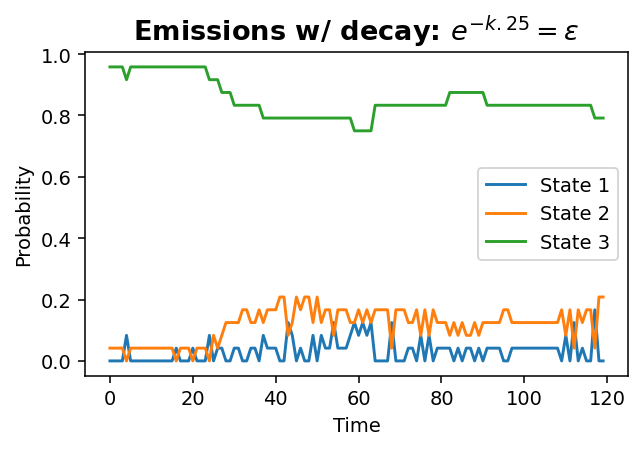

In [ ]:
plt.figure(figsize=(5, 3))

plt.plot(np.arange(120), prob_0, label='State 1')
plt.plot(np.arange(120), prob_1, label='State 2')
plt.plot(np.arange(120), prob_2, label='State 3')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Probability')
plt.title('Emissions w/ decay: $e^{-k} = \epsilon$', fontsize=14, weight='bold')

Text(0.5, 1.0, 'Emissions: $p(rt_{t}) \\sim N(w*time_{t} + b, \\sigma^2)$')

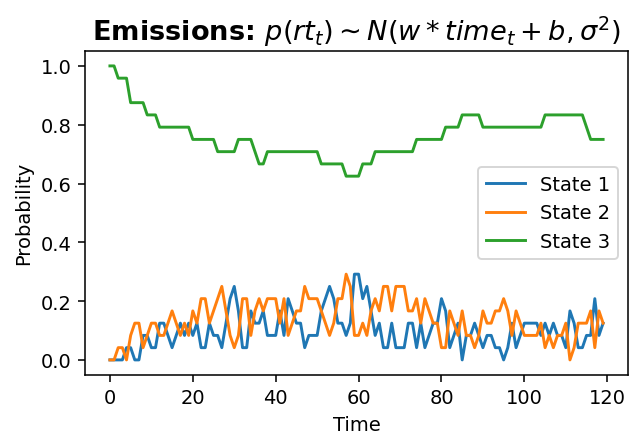

In [182]:
plt.figure(figsize=(5, 3))

plt.plot(np.arange(120), prob_0, label='State 1')
plt.plot(np.arange(120), prob_1, label='State 2')
plt.plot(np.arange(120), prob_2, label='State 3')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Probability')
plt.title('Emissions: $p(rt_{t}) \sim N(w*time_{t} + b, \sigma^2)$', fontsize=14, weight='bold')

## Global initializer

In [6]:
num_states, input_dim, emission_dim = 2, 3, 1

In [ ]:
global_params = {}

for nstate in tqdm(range(2, 10)):
    model = CircularRegressionHMM(nstate, input_dim, emission_dim)
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    subset_idx = np.random.choice(np.arange(0, len(emissions)), len(emissions), replace=False)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions[subset_idx], inputs = inputs[subset_idx], num_iters = 100, verbose = False)
    global_params[nstate] = fit_params

In [ ]:
# with open('./caches/global_params.pkl', 'wb') as f:
#     pickle.dump(global_params, f)
    
# with open('./caches/global_params.pkl', 'rb') as f:
#     global_params = pickle.load(f)

In [7]:
# num_states, input_dim, emission_dim = 2, 3, 1
# global_crossval = {}

# for nstate in tqdm(range(2, 10)):
#     model = CircularRegressionHMM(nstate, input_dim, emission_dim)
#     # make index of emissions size and shufflei t
#     shuffled_indices = np.random.permutation(emissions.shape[0])
#     parameters, properties = model.initialize(key=jr.PRNGKey(nstate), method="kmeans", emissions = emissions[shuffled_indices])
#     ll_mean, ll = cross_validate_regressor(model=model, emissions=emissions[shuffled_indices], key=jr.PRNGKey(0), num_iters=100, inputs=inputs[shuffled_indices])
#     global_crossval[nstate] = ll

In [ ]:
# with open('./caches/global_crossval.pkl', 'wb') as f:
#     pickle.dump(global_crossval, f)
    
# with open('./caches/global_crossval.pkl', 'rb') as f:
#     global_crossval = pickle.load(f)

## Crossvalidate subject models LOO

In [ ]:
# with open('./caches/sub_crossval_results.pkl', 'wb') as f:
#     pickle.dump(crossval_results, f)
# with open('./caches/sub_crossval_results.pkl', 'rb') as f:
#     crossval_results = pickle.load(f)

## Subject models

Therefore according to the cross val, it suggests x states so now we full train on those x states

In [ ]:
# subject_params = {}

# for idx, (s_em, s_in) in enumerate(zip(emissions.reshape(12, 4 * 6, 120, 1), inputs.reshape(12, 4 * 6, 120, 3))):
#     subject_params[idx] = {}
#     shuffle_idx = np.random.permutation(len(s_em))
    
#     nstate = 2
#     model = CircularRegressionHMM(nstate, input_dim, emission_dim)
#     gpar = global_params[nstate]
#     parameters, properties = model.initialize(key=jr.PRNGKey(1), 
#                                                 method="prior",
#                                                 initial_probs=gpar.initial.probs,
#                                                 transition_matrix=gpar.transitions.transition_matrix,
#                                                 emission_weights=gpar.emissions.weights,
#                                                 emission_biases=gpar.emissions.biases,
#                                                 emission_covariances=gpar.emissions.covs,)
#     fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = s_em[shuffle_idx], inputs = s_in[shuffle_idx], num_iters = 100, verbose = False)
    
#     subject_params[idx][nstate] = fit_params

In [ ]:
# with open('./caches/subject_params.pkl', 'wb') as f:
#     pickle.dump(subject_params, f)
    
# with open('./caches/subject_params.pkl', 'rb') as f:
#     subject_params = pickle.load(f)

## Condition fits

In [15]:
emissions.shape

(288, 120, 1)

In [16]:
# expected data 
expected_em = emissions.reshape(12, 4, 6, 120, 1)[:,:,:5,:,:]
expected_in = inputs.reshape(12, 4, 6, 120, 3)[:,:,:5,:,:]

unexpected_em = emissions.reshape(12, 4, 6, 120, 1)[:,:,5:,:,:]
unexpected_in = inputs.reshape(12, 4, 6, 120, 3)[:,:,5:,:,:]

expected_em.shape, expected_in.shape, unexpected_em.shape, unexpected_in.shape

((12, 4, 5, 120, 1),
 (12, 4, 5, 120, 3),
 (12, 4, 1, 120, 1),
 (12, 4, 1, 120, 3))

In [17]:
# cond_params = {}
# nstate = 2

# names = ["unexpected", "expected"]

# for (cem, cin), name in zip(((unexpected_em, unexpected_in), (expected_em, expected_in)), names):
#     cond_params[name] = {}
    
#     for idx in tqdm(range(12), desc=f'{name}'):
        
#         em = jnp.array(cem[idx].reshape(-1, 120, 1))
#         inps = jnp.array(cin[idx].reshape(-1, 120, 3))
#         shuffle_idx = np.random.permutation(len(em))
#         model = CircularRegressionHMM(nstate, input_dim, emission_dim)
        
#         gpar = subject_params[idx][nstate]
#         parameters, properties = model.initialize(key=jr.PRNGKey(1), 
#                                                     method="prior",
#                                                     initial_probs=gpar.initial.probs,
#                                                     transition_matrix=gpar.transitions.transition_matrix,
#                                                     emission_weights=gpar.emissions.weights,
#                                                     emission_biases=gpar.emissions.biases,
#                                                     emission_covariances=gpar.emissions.covs,)
#         fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = em[shuffle_idx], inputs = inps[shuffle_idx], num_iters = 100, verbose = False)
        
#         cond_params[name][idx] = fit_params

In [18]:
# with open('./caches/cond_params.pkl', 'wb') as f:
#     pickle.dump(cond_params, f)
    
with open('./caches/cond_params.pkl', 'rb') as f:
    cond_params = pickle.load(f)

# ML STATE

In [19]:
ml_states = {}
nstate = 2

names = ["unexpected", "expected"]

for (cem, cin), name in zip(((unexpected_em, unexpected_in), (expected_em, expected_in)), names):
    ml_states[name] = {}
    
    for idx in tqdm(range(12), desc=f'{name}'):
        
        shuffle_idx = np.random.permutation(len(cem[idx].reshape(-1, 120, 1)))
        em = jnp.array(cem[idx].reshape(-1, 120, 1)[shuffle_idx])
        inps = jnp.array(cin[idx].reshape(-1, 120, 3)[shuffle_idx])
        model = CircularRegressionHMM(nstate, input_dim, emission_dim)
        
        gpar = subject_params[idx][nstate]
        parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                                    method="prior",
                                                    initial_probs=gpar.initial.probs,
                                                    transition_matrix=gpar.transitions.transition_matrix,
                                                    emission_weights=gpar.emissions.weights,
                                                    emission_biases=gpar.emissions.biases,
                                                    emission_covariances=gpar.emissions.covs,)
        # fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = em[shuffle_idx], inputs = inps[shuffle_idx], num_iters = 100, verbose = False)
        # Define a vmapped version of most_likely_states.
        # This applies the function to each trial in the batch dimension of `em`.
        most_likely_states_vmap = vmap(lambda trial, inp: model.most_likely_states(parameters, trial, inp))
        t_trail = most_likely_states_vmap(em, inps)
        ml_states[name][idx] = t_trail

expected: 100%|██████████| 12/12 [00:00<00:00, 14.10it/s]


In [ ]:
# with open('./caches/ml_states.pkl', 'wb') as f:
#     pickle.dump(ml_states, f)
    
# with open('./caches/ml_states.pkl', 'rb') as f:
#     ml_states = pickle.load(f)